In [13]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import sympy as sp

k = 3
N = 2**k
M = N
L=M
a = 0
b = 1
c = 0
d = 1
l = 0
m = 1
hx = (b - a) / (N + 1)
hy = (d - c) / (M + 1)
hz = (m - l) / (L + 1)

x_full = np.linspace(a, b, N + 2)
y_full = np.linspace(c, d, M + 2)
z_full = np.linspace(l, m, L + 2)

X_full, Y_full = np.meshgrid(x_full, y_full, indexing='ij')
Xf,Yf,Zf=np.meshgrid(x_full, y_full,z_full, indexing='ij')


u1_true= np.sin(2 * np.pi * x_full)
u2_true = np.sin(2 * np.pi * X_full) * np.sin(2 * np.pi * Y_full)
u3_true = np.sin(2 * np.pi * Xf) * np.sin(2 * np.pi * Yf)* np.sin(2 * np.pi * Zf)

In [14]:
#plot true dim = 2
'''
fig = go.Figure(data=[go.Surface(z=u2_full, x=X_full, y=Y_full)])
fig.update_layout(title='u2 true', autosize=False, width=800, height=600)
fig.show()
'''
#plot true dim = 2
'''
fig = go.Figure(data=[go.Surface(z=u2_full, x=X_full, y=Y_full)])
fig.update_layout(title='u2 true', autosize=False, width=800, height=600)
fig.show()
'''
# Plot true dim = 3
'''
fig3 = go.Figure(data=go.Volume(
    x=Xf.flatten(),
    y=Yf.flatten(),
    z=Zf.flatten(),
    value=u3_full.flatten(),
    isomin=-0.9,
    isomax=0.9,
    opacity=0.1, # needs to be small to see through all surfaces
    surface_count=21, # needs to be a large number for good volume rendering
    ))
fig3.update_layout(title='u3 true')
fig3.show()
'''

"\nfig3 = go.Figure(data=go.Volume(\n    x=Xf.flatten(),\n    y=Yf.flatten(),\n    z=Zf.flatten(),\n    value=u3_full.flatten(),\n    isomin=-0.9,\n    isomax=0.9,\n    opacity=0.1, # needs to be small to see through all surfaces\n    surface_count=21, # needs to be a large number for good volume rendering\n    ))\nfig3.update_layout(title='u3 true')\nfig3.show()\n"

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10612\2055124416.py:33: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



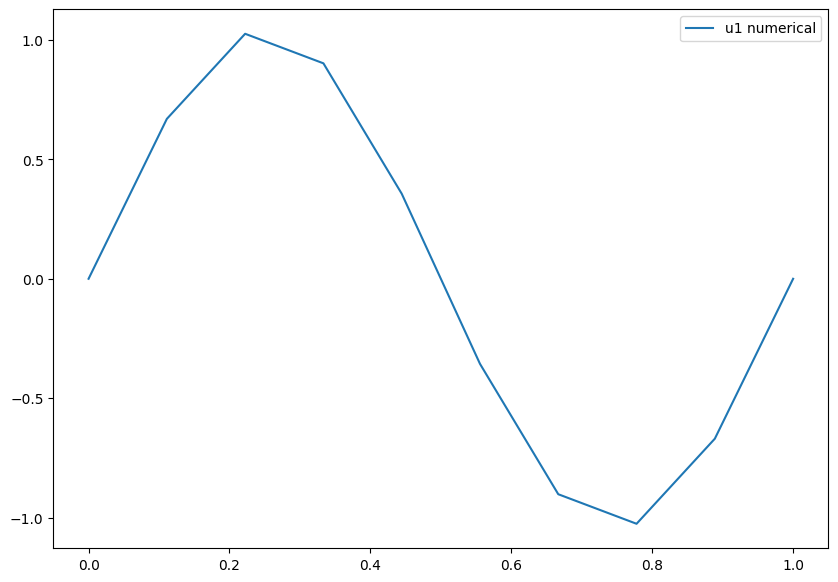

In [15]:
# Compute f symbolically
x, y, z = sp.symbols('x y z')
u1_sym = sp.sin(2 * sp.pi * x)
u2_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y)
u3_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y) * sp.sin(2 * sp.pi * z)
f1_sym = sp.diff(u1_sym, x, 2)
f2_sym = sp.diff(u2_sym, x, 2) + sp.diff(u2_sym, y, 2)
f3_sym = sp.diff(u3_sym, x, 2) + sp.diff(u3_sym, y, 2) + sp.diff(u3_sym, z, 2)
f1_func = sp.lambdify((x), f1_sym, 'numpy')
f2_func = sp.lambdify((x, y), f2_sym, 'numpy')
f3_func = sp.lambdify((x, y, z), f3_sym, 'numpy')
f1 = f1_func(x_full[1:-1])
f2 = f2_func(X_full[1:-1, 1:-1], Y_full[1:-1, 1:-1])
f3 = f3_func(Xf[1:-1, 1:-1, 1:-1], Yf[1:-1, 1:-1, 1:-1], Zf[1:-1, 1:-1, 1:-1])
# Flatten f to get the right-hand side vector b
b1 = f1.ravel()
b2 = f2.ravel()
b3 = f3.ravel()
#Discrete Laplacian
from FD import FDlapl_homo
A1 = FDlapl_homo(1,N,hx)
A2 = FDlapl_homo(2,N,hx,M,hy)
A3 = FDlapl_homo(3,N,hx,M,hy,L,hz)

# Solve the system 
u1 = np.linalg.solve(A1, b1)
u1_full=np.zeros(len(u1)+2)
u1_full[1:N+1] = u1

fig1=plt.figure(figsize=(10,7))
plt.plot(x_full, u1_full, label='u1 numerical')
plt.legend()
fig1.show()


In [16]:
u2 = np.linalg.solve(A2, b2)
u2_full=np.zeros((N+2,M+2))
u2_full[1:N+1,1:M+1] = u2.reshape(N,M)
fig = go.Figure(data=[go.Surface(z=u2_full, x=X_full, y=Y_full)])
fig.update_layout(title='u2 numerical', autosize=False, width=800, height=600)
fig.show()

In [17]:
u3 = np.linalg.solve(A3, b3)
u3_full=np.zeros((N+2,M+2,L+2))
u3_full[1:N+1,1:M+1,1:L+1] = u3.reshape(M,N,L)
fig3 = go.Figure(data=go.Volume(
    x=Xf.flatten(),
    y=Yf.flatten(),
    z=Zf.flatten(),
    value=u3_full.flatten(),
    isomin=-0.9,
    isomax=0.9,
    opacity=0.1, # needs to be small to see through all surfaces
    surface_count=21, # needs to be a large number for good volume rendering
    ))
fig3.update_layout(title='u3 numerical')
fig3.show()

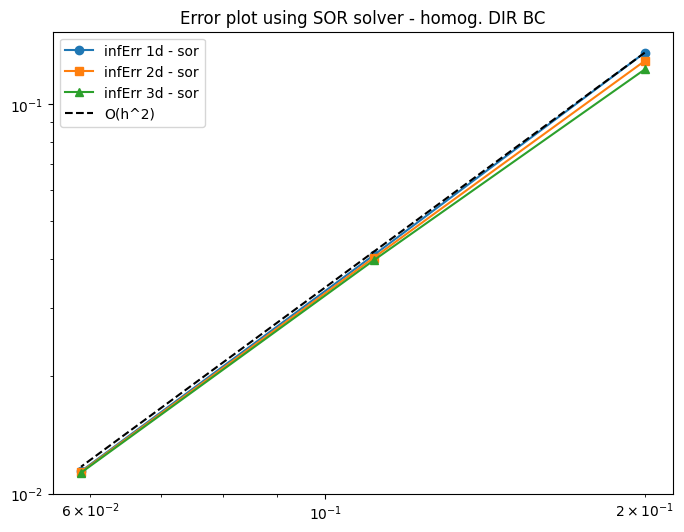

In [18]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import time
import tracemalloc
from FD import FDlapl_homo
from custom_solvers import sor, jacobi, gseidel


H=[]
E1=[]
E2=[]
E3=[]
t1=[]
mem1=[]
t2=[]
mem2=[]
t3=[]
mem3=[]
NN=[]
METH=[]
K=[2,3,4] # sor for 2,3,4 takes 2 min approx.
for meth in ['sor']:
    for k in K: 
        N = 2**k
        M = N
        L=M
        a = 0
        b = 1
        c = 0
        d = 1
        l = 0
        m = 1
        hx = (b - a) / (N + 1)
        hy = (d - c) / (M + 1)
        hz = (m - l) / (L + 1)

        x_full = np.linspace(a, b, N + 2)
        y_full = np.linspace(c, d, M + 2)
        z_full = np.linspace(l, m, L + 2)

        X_full, Y_full = np.meshgrid(x_full, y_full, indexing='ij')
        Xf,Yf,Zf=np.meshgrid(x_full, y_full,z_full, indexing='ij')

        u1_true= np.sin(2 * np.pi * x_full)
        u2_true = np.sin(2 * np.pi * X_full) * np.sin(2 * np.pi * Y_full)
        u3_true = np.sin(2 * np.pi * Xf) * np.sin(2 * np.pi * Yf)* np.sin(2 * np.pi * Zf)

        x, y, z = sp.symbols('x y z')
        u1_sym = sp.sin(2 * sp.pi * x)
        u2_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y)
        u3_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y) * sp.sin(2 * sp.pi * z)
        f1_sym = sp.diff(u1_sym, x, 2)
        f2_sym = sp.diff(u2_sym, x, 2) + sp.diff(u2_sym, y, 2)
        f3_sym = sp.diff(u3_sym, x, 2) + sp.diff(u3_sym, y, 2) + sp.diff(u3_sym, z, 2)
        f1_func = sp.lambdify((x), f1_sym, 'numpy')
        f2_func = sp.lambdify((x, y), f2_sym, 'numpy')
        f3_func = sp.lambdify((x, y, z), f3_sym, 'numpy')
        f1 = f1_func(x_full[1:-1])
        f2 = f2_func(X_full[1:-1, 1:-1], Y_full[1:-1, 1:-1])
        f3 = f3_func(Xf[1:-1, 1:-1, 1:-1], Yf[1:-1, 1:-1, 1:-1], Zf[1:-1, 1:-1, 1:-1])

        b1 = f1.ravel()
        b2 = f2.ravel()
        b3 = f3.ravel()

        A1 = FDlapl_homo(1,N,hx)
        A2 = FDlapl_homo(2,N,hx,M,hy)
        A3 = FDlapl_homo(3,N,hx,M,hy,L,hz)

        # 1D
        if meth=='jacobi':
            t_start = time.perf_counter()
            tracemalloc.start()
            u1,niter = jacobi(A1, b1)
            runtime = time.perf_counter() - t_start
            t1.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            mem1.append(peak_bytes/ 1024)
            tracemalloc.stop()
        if meth=='gs':
            t_start = time.perf_counter()
            tracemalloc.start()
            u1, niter = gseidel(A1, b1)
            runtime = time.perf_counter() - t_start
            t1.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            mem1.append(peak_bytes/ 1024)
            tracemalloc.stop()
        if meth=='sor':
            t_start = time.perf_counter()
            tracemalloc.start()
            u1,iter,err = sor(A1, b1, 1.9)
            runtime = time.perf_counter() - t_start
            t1.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            mem1.append(peak_bytes/ 1024)
            tracemalloc.stop()
        u1_full=np.zeros(len(u1)+2)
        u1_full[1:N+1] = u1
    # 2D
        if meth=='jacobi':
            t_start = time.perf_counter()
            tracemalloc.start()
            u2, niter = jacobi(A2, b2)
            runtime = time.perf_counter() - t_start
            t2.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            mem2.append(peak_bytes/ 1024)
            tracemalloc.stop()
        if meth=='gs':
            t_start = time.perf_counter()
            tracemalloc.start()
            u2, niter = gseidel(A2, b2)
            runtime = time.perf_counter() - t_start
            t2.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            mem2.append(peak_bytes/ 1024)
            tracemalloc.stop()
        if meth=='sor':
            t_start = time.perf_counter()
            tracemalloc.start()
            u2,iter,err = sor(A2, b2, 1.9)
            runtime = time.perf_counter() - t_start
            t2.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            mem2.append(peak_bytes/ 1024)
            tracemalloc.stop()

        u2_full=np.zeros((N+2,M+2))
        u2_full[1:N+1,1:M+1] = u2.reshape(N,M)
    # 3D
        if meth=='jacobi':
            t_start = time.perf_counter()
            tracemalloc.start()
            u3, niter = jacobi(A3, b3)
            runtime = time.perf_counter() - t_start
            t3.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            mem3.append(peak_bytes/ 1024)
            tracemalloc.stop()
        if meth=='gs':
            t_start = time.perf_counter()
            tracemalloc.start()
            u3, niter = gseidel(A3, b3)
            runtime = time.perf_counter() - t_start
            t3.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            mem3.append(peak_bytes/ 1024)
            tracemalloc.stop()
        if meth=='sor':
            t_start = time.perf_counter()
            tracemalloc.start()
            u3,iter,err = sor(A3, b3, 1.9)
            runtime = time.perf_counter() - t_start
            t3.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()
            mem3.append(peak_bytes/ 1024)

        u3_full=np.zeros((N+2,M+2,L+2))
        u3_full[1:N+1,1:M+1,1:L+1] = u3.reshape(M,N,L)

        e1=np.max(np.abs(u1_full-u1_true))
        e2=np.max(np.abs(u2_full-u2_true))
        e3=np.max(np.abs(u3_full-u3_true))
        METH.append(meth)
        NN.append(N)
        E1.append(e1)
        E2.append(e2)
        E3.append(e3)
        H.append(hx)

plt.figure(figsize=(8,6))
plt.loglog(H[0:len(K)], E1[0:len(K)], 'o-', label='infErr 1d - sor')
plt.loglog(H[0:len(K)], E2[0:len(K)], 's-',  label='infErr 2d - sor')
plt.loglog(H[0:len(K)], E3[0:len(K)], '^-',  label='infErr 3d - sor')
plt.loglog(H, (E1[0]/H[0]**2)*np.pow(H,2), '--', color='black', label='O(h^2)')
plt.title('Error plot using SOR solver - homog. DIR BC')
plt.legend()


In [19]:
results=[METH,NN,H,t2,t3,mem2,mem3]
col = [10,10,10, 15, 15, 15,15]
header = (f"{'Method:':<{col[0]}}{'N:':<{col[1]}}{'h:':<{col[2]}}{'Time2D(s):':<{col[3]}} {'Time3D(s):':>{col[4]}} {'Mem2D(KB):':>{col[5]}}{'Mem3D(KB):':>{col[6]}}")
sep = "-" * sum(2*col)
print(header)
print(sep)
for i in range(len(H)):
    print(f"{results[0][i]:<{col[0]}} {results[1][i]:<{col[1]}} {results[2][i]:<{col[2]}.3f} {results[3][i]:>{col[3]}.3f}{results[4][i]:>{col[4]}.3f} {results[5][i]:>{col[5]}.1f} {results[6][i]:>{col[6]}.1f} ")
print(sep)

Method:   N:        h:        Time2D(s):           Time3D(s):      Mem2D(KB):     Mem3D(KB):
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
sor        4          0.200                0.172          0.663             1.1             1.5 
sor        8          0.111                0.663          7.708             1.5             5.8 
sor        16         0.059                2.935         84.382             3.0            34.0 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


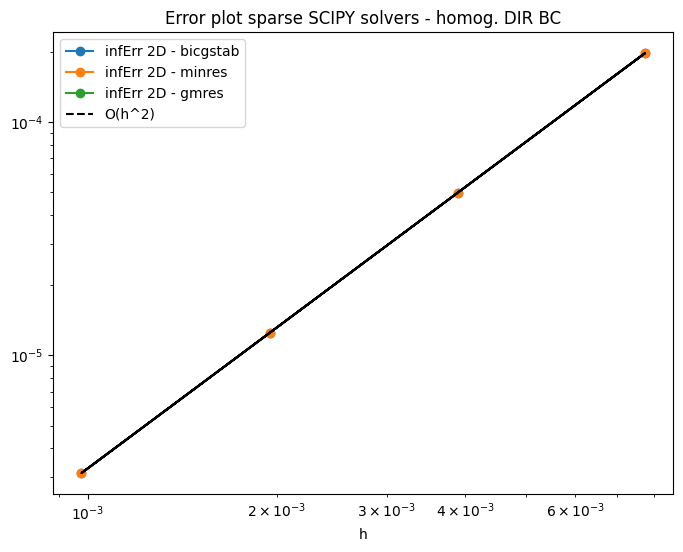

Method:   N:   h:        Time2D(s):  Mem2D(KB):
------------------------------------------------------------------------------------------
bicgstab   128   0.008           0.002      897.7
bicgstab   256   0.004           0.003     3585.7
bicgstab   512   0.002           0.013    14337.7
bicgstab   1024  0.001           0.057    57345.7
minres     128   0.008           0.003     1153.9
minres     256   0.004           0.005     4609.9
minres     512   0.002           0.013    18433.9
minres     1024  0.001           0.093    73729.9
gmres      128   0.008           0.004     3333.9
gmres      256   0.004           0.008    13317.9
gmres      512   0.002           0.016    53253.9
gmres      1024  0.001           0.107   212997.9
------------------------------------------------------------------------------------------


In [20]:
from scipy.sparse.linalg import minres, cg, gmres, bicgstab
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import time
import tracemalloc
from scipy.sparse.linalg import spsolve, eigs
from FD import FDlapl_homo_sparse

x, y, z = sp.symbols('x y z')
u2_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y)
f2_sym = sp.diff(u2_sym, x, 2) + sp.diff(u2_sym, y, 2)
f2_func = sp.lambdify((x, y), f2_sym, 'numpy')


H=[]
E1=[]
E2=[]
E3=[]
t1=[]
mem1=[]
t2=[]
mem2=[]
t3=[]
mem3=[]
Meth=[]
NN=[]
cond2=[]
cond3=[]

K=[7,8,9,10] 
for meth in ['bicgstab','minres','gmres']:
    for k in K: 
        N = 2**k
        M = N
        L=M
        a = 0
        b = 1
        c = 0
        d = 1
        l = 0
        m = 1
        hx = (b - a) / (N + 1)
        hy = (d - c) / (M + 1)
        hz = (m - l) / (L + 1)

        x_full = np.linspace(a, b, N + 2)
        y_full = np.linspace(c, d, M + 2)

        X_full, Y_full = np.meshgrid(x_full, y_full, indexing='ij')

        u2_true = np.sin(2 * np.pi * X_full) * np.sin(2 * np.pi * Y_full)
 
        f2 = f2_func(X_full[1:-1, 1:-1], Y_full[1:-1, 1:-1])

        b2 = f2.ravel()
        u2=np.zeros_like(u2_true)

        A2 = FDlapl_homo_sparse(2,N,hx,M,hy)
      
        spymatrix=0
        if k==7 and meth=='cg' and spymatrix:
            print(np.shape(A2))
            print('<- shape of A2; k=7; plt.spy(A2) ->')
            plt.spy(A2)
            print(A2)
            vals, vect=eigs(A2)
            print('pos def if: ')
            print(np.min(vals))
            print('>0')
# 2D
        if meth=='cg':
            tracemalloc.start()
            t_start = time.perf_counter()
            u2, exitCode = cg(A2, b2,atol=1e-5)
            runtime = time.perf_counter() - t_start
            t2.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()
            mem2.append((peak_bytes/ 1024))
        elif meth=='minres':
            tracemalloc.start()
            t_start = time.perf_counter()
            u2, exitCode = minres(A2, b2, rtol=1e-5)
            runtime = time.perf_counter() - t_start
            t2.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()
            mem2.append((peak_bytes/ 1024))
        elif meth=='spsolve':
            tracemalloc.start()
            t_start = time.perf_counter()
            u2 = spsolve(A2, b2)
            runtime = time.perf_counter() - t_start
            t2.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()
            mem2.append((peak_bytes/ 1024))
        elif meth=='gmres': 
            t_start = time.perf_counter()
            tracemalloc.start()
            u2, exitCode = gmres(A2, b2, atol=1e-5)
            runtime = time.perf_counter() - t_start
            t2.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()
            mem2.append((peak_bytes/ 1024))
        elif meth=='bicgstab':
            t_start = time.perf_counter()
            tracemalloc.start()
            u2, exitCode = bicgstab(A2, b2, atol=1e-5)
            runtime = time.perf_counter() - t_start
            t2.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()
            mem2.append((peak_bytes/ 1024))

        u2_full=np.zeros((N+2,M+2))
        u2_full[1:N+1,1:M+1] = u2.reshape(N,M)

        e2=np.max(np.abs(u2_full-u2_true))
        E2.append(e2)
        NN.append(N)
        H.append(hx)
        Meth.append(meth)

plt.figure(figsize=(8,6))
plt.loglog(H[0:len(K)], E2[0:len(K)], 'o-', label='infErr 2D - bicgstab')
plt.loglog(H[len(K):2*len(K)], E2[len(K):2*len(K)], 'o-',  label='infErr 2D - minres')
plt.loglog(H[3*len(K):4*len(K)], E2[3*len(K):4*len(K)], 'o-',  label='infErr 2D - gmres')


plt.loglog(H, np.power(H,2)*(E2[0]/H[0]**2), '--', color='black', label='O(h^2)')
plt.title('Error plot sparse SCIPY solvers - homog. DIR BC')
plt.xlabel('h')
plt.legend()
plt.show()

results=[Meth,NN,H,t2,mem2]
col = [10,5,5, 15, 10]
header = (f"{'Method:':<{col[0]}}{'N:':<{col[1]}}{'h:':<{col[2]}}{'Time2D(s):':>{col[3]}}  {'Mem2D(KB):':>{col[4]}}")
sep = "-" * sum(2*col)
print(header)
print(sep)
for i in range(len(H)):
    print(f"{results[0][i]:<{col[0]}} {results[1][i]:<{col[1]}} {results[2][i]:<{col[2]}.3f} {results[3][i]:>{col[3]}.3f} {results[4][i]:>{col[4]}.1f}")
print(sep)


In [21]:
from scipy.sparse.linalg import bicgstab, eigs, minres
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import time
import tracemalloc

x, y, z = sp.symbols('x y z')
u3_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y) * sp.sin(2 * sp.pi * z)
f3_sym = sp.diff(u3_sym, x, 2) + sp.diff(u3_sym, y, 2) + sp.diff(u3_sym, z, 2)
f3_func = sp.lambdify((x, y, z), f3_sym, 'numpy')
H=[]
E3=[]
t3=[]
mem3=[]
Meth=[]
NN=[]

for meth in ['gmres','bicgstab']:
    for k in [6,7,8]: 
        N = 2**k
        M = N
        L=M
        a = 0
        b = 1
        c = 0
        d = 1
        l = 0
        m = 1
        hx = (b - a) / (N + 1)
        hy = (d - c) / (M + 1)
        hz = (m - l) / (L + 1)

        x_full = np.linspace(a, b, N + 2)
        y_full = np.linspace(c, d, M + 2)
        z_full = np.linspace(l, m, L + 2)
        Xf,Yf,Zf=np.meshgrid(x_full, y_full,z_full, indexing='ij')
        u3_true = np.sin(2 * np.pi * Xf) * np.sin(2 * np.pi * Yf)* np.sin(2 * np.pi * Zf)
        f3 = f3_func(Xf[1:-1, 1:-1, 1:-1], Yf[1:-1, 1:-1, 1:-1], Zf[1:-1, 1:-1, 1:-1])
        b3 = f3.ravel()

        A3 = FDlapl_homo_sparse(3,N,hx,M,hy,L,hz)
        spymatrix=0
        if k==6 and spymatrix:
            print(np.shape(A3))
            print('<- shape of A2; k=7; plt.spy(A2) ->')
            plt.spy(A2)
            vals, vect=eigs(A3)
            print('pos def if: ')
            print(np.min(vals))
            print('>0')
        # 3D
        if meth=='gmres':
            t_start = time.perf_counter()
            tracemalloc.start()
            u3, exitCode = gmres(A3, b3, rtol=1e-5)
            runtime = time.perf_counter() - t_start
            t3.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()
            mem3.append((peak_bytes/ 1024))
        if meth=='bicgstab':
            t_start = time.perf_counter()
            tracemalloc.start()
            u3, exitCode = bicgstab(A3, b3, atol=1e-5)
            runtime = time.perf_counter() - t_start
            t3.append(runtime)
            peak_bytes = max(tracemalloc.get_traced_memory())
            tracemalloc.stop()
            mem3.append((peak_bytes/ 1024))
        
        u3_full=np.zeros((N+2,M+2,L+2))
        u3_full[1:N+1,1:M+1,1:L+1] = u3.reshape(M,N,L)
    
        e3=np.max(np.abs(u2_full-u2_true))
        E3.append(e3)
        NN.append(N)
        H.append(hx)
        Meth.append(meth)


results=[Meth,NN,H,t3,mem3]
col = [10,5,5, 15, 10]
header = (f"{'Method:':<{col[0]}}{'N:':<{col[1]}}{'h:':<{col[2]}}{'Time3D(s):':>{col[3]}}  {'Mem3D(KB):':>{col[4]}}")
sep = "-" * sum(2*col)
print(header)
print(sep)
for i in range(len(H)):
    print(f"{results[0][i]:<{col[0]}} {results[1][i]:<{col[1]}} {results[2][i]:<{col[2]}.3f} {results[3][i]:>{col[3]}.3f} {results[4][i]:>{col[4]}.1f}")
print(sep)

Method:   N:   h:        Time3D(s):  Mem3D(KB):
------------------------------------------------------------------------------------------
gmres      64    0.015           0.018    53253.9
gmres      128   0.008           0.226   425989.9
gmres      256   0.004           1.482  3407877.9
bicgstab   64    0.015           0.018    14337.7
bicgstab   128   0.008           0.099   114689.7
bicgstab   256   0.004           0.787   917505.7
------------------------------------------------------------------------------------------


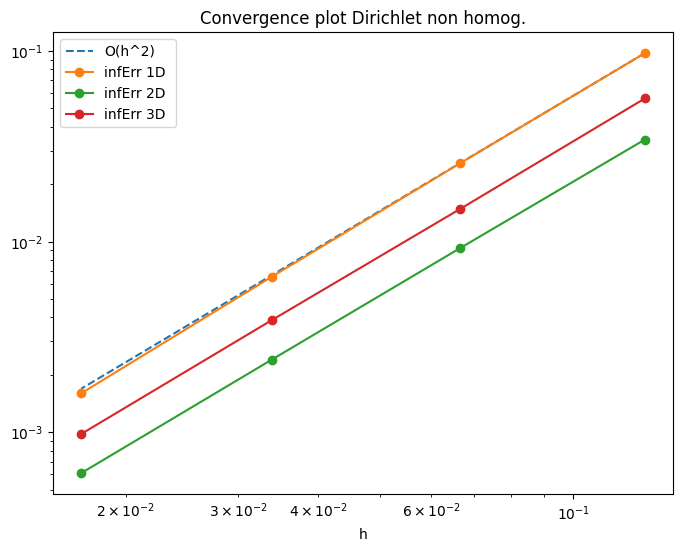

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import sympy as sp
from FD import FDlapl_robin_sparse, rhs_robin, dir_mask_val, apply_dir
from scipy.sparse.linalg import bicgstab

H=[]
E1=[]
E2=[]
E3=[]
t1=[]
mem1=[]
t2=[]
mem2=[]
t3=[]
mem3=[]
Meth=[]
NN=[]
cond2=[]
cond3=[]

# Test non-homog. Dir
alpha1 = {'L': 0, 'R': 0}
beta1 = {'L': 1, 'R': 1}
alpha2 = {'L': 0, 'R': 0, 'B': 0, 'T': 0}
beta2 = {'L': 1, 'R': 1, 'B': 1, 'T': 1}
alpha3 = {'L': 0, 'R': 0, 'B': 0, 'T': 0, 'D': 0, 'U': 0}
beta3 = {'L': 1, 'R': 1, 'B': 1, 'T': 1, 'D': 1, 'U': 1}

plotnumvstrue=0

K=[4,5,6,7] # 7 : 1miin  approx. with bicgstab
for k in K: 
    N = 2**k
    M = N
    L=M
    a = 0.3
    b = 2.5
    c = 0.5
    d = 1.2
    l = 0
    m = 3
    hx = (b - a) / (N + 1)
    hy = (d - c) / (M + 1)
    hz = (m - l) / (L + 1)

    x_full = np.linspace(a, b, N + 2)
    y_full = np.linspace(c, d, M + 2)
    z_full = np.linspace(l, m, L + 2)

    X_full, Y_full = np.meshgrid(x_full, y_full, indexing='ij')
    Xf,Yf,Zf=np.meshgrid(x_full, y_full,z_full, indexing='ij')


    u1_true= np.sin(2 * np.pi * x_full)
    u2_true = np.sin(2 * np.pi * X_full) * np.sin(2 * np.pi * Y_full)
    u3_true = np.sin(2 * np.pi * Xf) * np.sin(2 * np.pi * Yf)* np.sin(2 * np.pi * Zf)

    x, y, z = sp.symbols('x y z')
    u1_sym = sp.sin(2 * sp.pi * x)
    u2_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y)
    u3_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y) * sp.sin(2 * sp.pi * z)
    f1_sym = sp.diff(u1_sym, x, 2)
    f2_sym = sp.diff(u2_sym, x, 2) + sp.diff(u2_sym, y, 2)
    f3_sym = sp.diff(u3_sym, x, 2) + sp.diff(u3_sym, y, 2) + sp.diff(u3_sym, z, 2)
    f1_func = sp.lambdify((x), f1_sym, 'numpy')
    f2_func = sp.lambdify((x, y), f2_sym, 'numpy')
    f3_func = sp.lambdify((x, y, z), f3_sym, 'numpy')

    f1 = f1_func(x_full)
    f2 = f2_func(X_full, Y_full)
    f3 = f3_func(Xf, Yf, Zf)

    u1x = sp.diff(u1_sym, x, 1)
    u2x = sp.diff(u2_sym, x, 1)
    u2y = sp.diff(u2_sym, y, 1)
    u3x = sp.diff(u3_sym, x, 1)
    u3y = sp.diff(u3_sym, y, 1)
    u3z = sp.diff(u3_sym, z, 1)
    g1L=alpha1['L']*(-u1x)+beta1['L']*u1_sym; g1L=sp.lambdify((x), g1L, 'numpy')
    g1R=alpha1['R']*(u1x)+beta1['R']*u1_sym; g1R=sp.lambdify((x), g1R, 'numpy')
    g1={'L': g1L, 'R': g1R}
    g2L=alpha2['L']*(-u2x)+beta2['L']*u2_sym; g2L=sp.lambdify((x, y), g2L, 'numpy')
    g2R=alpha2['R']*(u2x)+beta2['R']*u2_sym; g2R=sp.lambdify((x, y), g2R, 'numpy')
    g2B=alpha2['B']*(-u2y)+beta2['B']*u2_sym; g2B=sp.lambdify((x, y), g2B, 'numpy')
    g2T=alpha2['T']*(u2y)+beta2['T']*u2_sym; g2T=sp.lambdify((x, y), g2T, 'numpy')
    g2={'L': g2L, 'R': g2R, 'B': g2B, 'T': g2T}
    g3L=alpha3['L']*(-u3x)+beta3['L']*u3_sym; g3L=sp.lambdify((x, y, z), g3L, 'numpy')
    g3R=alpha3['R']*(u3x)+beta3['R']*u3_sym; g3R=sp.lambdify((x, y, z), g3R, 'numpy')
    g3B=alpha3['B']*(-u3y)+beta3['B']*u3_sym; g3B=sp.lambdify((x, y, z), g3B, 'numpy')
    g3T=alpha3['T']*(u3y)+beta3['T']*u3_sym; g3T=sp.lambdify((x, y, z), g3T, 'numpy')
    g3D=alpha3['D']*(-u3z)+beta3['D']*u3_sym; g3D=sp.lambdify((x, y, z), g3D, 'numpy')
    g3U=alpha3['U']*(u3z)+beta3['U']*u3_sym; g3U=sp.lambdify((x, y, z), g3U, 'numpy')
    g3={'L': g3L, 'R': g3R, 'B': g3B, 'T': g3T, 'D': g3D, 'U': g3U}

    # Flatten f to get the right-hand side vector b
    b1 = f1.ravel()
    b2 = f2.ravel()
    b3 = f3.ravel()

    A1   = FDlapl_robin_sparse(1, N, hx, alpha1, beta1)
    A2   = FDlapl_robin_sparse(2, N, hx, alpha2, beta2, M, hy)
    A3   = FDlapl_robin_sparse(3, N, hx, alpha3, beta3, M, hy, L, hz)

    rhs1 = rhs_robin(1, f1, N, hx, alpha1, g1, x_full)
    rhs2 = rhs_robin(2, f2, N, hx, alpha2, g2, x_full, M, hy, y_full)
    rhs3 = rhs_robin(3, f3, N, hx, alpha3, g3, x_full, M, hy, y_full, L, hz, z_full)

    mask1, uD1 = dir_mask_val(1, N, alpha1, beta1, g1, x_full)
    mask2, uD2 = dir_mask_val(2, N, alpha2, beta2, g2, x_full, M, y_full)
    mask3, uD3 = dir_mask_val(3, N, alpha3, beta3, g3, x_full, M, y_full, L, z_full)

    A1d, rhs1d = apply_dir(A1, rhs1, mask1, uD1)
    A2d, rhs2d = apply_dir(A2, rhs2, mask2, uD2)
    A3d, rhs3d = apply_dir(A3, rhs3, mask3, uD3)

    u1 = bicgstab(A1d, rhs1d)
    u2 = bicgstab(A2d, rhs2d)
    u3 = bicgstab(A3d, rhs3d)
    u1=u1[0]
    u2=u2[0].reshape(N+2,M+2)
    u3=u3[0].reshape(N+2,M+2,L+2)

    if plotnumvstrue:
        if k==6:
            fig= plt.figure(figsize=(12, 8))
            plt.plot(x_full, u1,         label='u1 numerical')
            plt.plot(x_full, u1_true, '--', label='u1 true')
            plt.title('1D — non-homog. Dirichlet')
            plt.legend()
            plt.show()

            fig2 = go.Figure(data=[go.Surface(z=u2, x=X_full, y=Y_full)])
            fig2.update_layout(title='u2 numerical', autosize=False, width=800, height=600)
            fig2.show()
            fig3 = go.Figure(data=[go.Surface(z=u2_true, x=X_full, y=Y_full)])
            fig3.update_layout(title='u2 true', autosize=False, width=800, height=600)
            fig3.show()
            # ── 3D plots ───────────────────────────────────────────────────────────────────
            fig4 = go.Figure(data=go.Volume(
                x=Xf.flatten(),
                y=Yf.flatten(),
                z=Zf.flatten(),
                value=u3_true.flatten(),
                isomin=-0.9,
                isomax=0.9,
                opacity=0.1, # needs to be small to see through all surfaces
                surface_count=21, # needs to be a large number for good volume rendering
                ))
            fig4.update_layout(title='u3 true')
            fig4.show()

            fig5 = go.Figure(data=go.Volume(
                x=Xf.flatten(),
                y=Yf.flatten(),
                z=Zf.flatten(),
                value=u3.flatten(),
                isomin=-0.9,
                isomax=0.9,
                opacity=0.1, # needs to be small to see through all surfaces
                surface_count=21, # needs to be a large number for good volume rendering
                ))
            fig5.update_layout(title='u3 numerical')
            fig5.show()

    e1=np.max(np.abs(u1-u1_true)); E1.append(e1)
    e2=np.max(np.abs(u2-u2_true)); E2.append(e2)
    e3=np.max(np.abs(u3-u3_true)); E3.append(e3)
    NN.append(N)
    H.append(hx)

plt.figure(figsize=(8,6))
plt.loglog(H, np.power(H,2)*(E1[0]/H[0]**2), '--', label='O(h^2)')
plt.loglog(H, E1, 'o-',  label='infErr 1D ')
plt.loglog(H, E2, 'o-',  label='infErr 2D ')
plt.loglog(H, E3, 'o-',  label='infErr 3D ')
plt.legend(); plt.xlabel('h')
plt.title('Convergence plot Dirichlet non homog.')
plt.show()

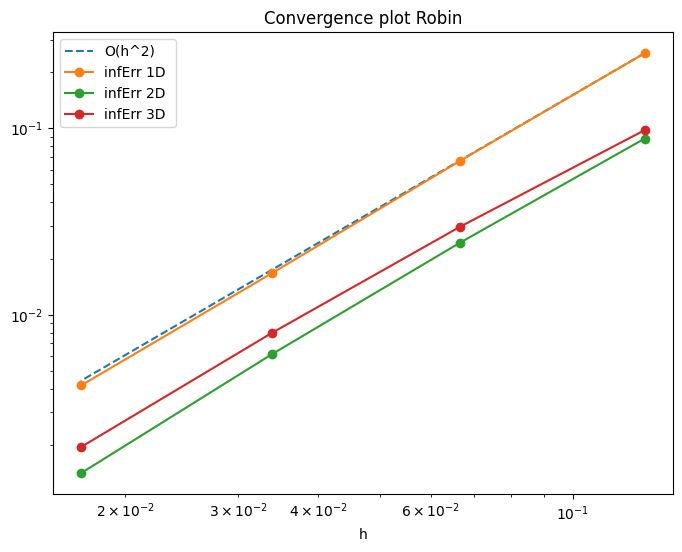

In [23]:

H=[]
E1=[]
E2=[]
E3=[]
t1=[]
mem1=[]
t2=[]
mem2=[]
t3=[]
mem3=[]
Meth=[]
NN=[]
cond2=[]
cond3=[]

# Test non-homog. Dir
alpha1 = {'L': 1, 'R': 1}
beta1 = {'L': 1, 'R': 1}
alpha2 = {'L': 1, 'R': 1, 'B': 1, 'T': 1}
beta2 = {'L': 1, 'R': 1, 'B': 1, 'T': 1}
alpha3 = {'L': 1, 'R': 1, 'B': 1, 'T': 1, 'D': 1, 'U': 1}
beta3 = {'L': 1, 'R': 1, 'B': 1, 'T': 1, 'D': 1, 'U': 1}

plotnumvstrue=0

K=[4,5,6,7] # 7 :1m  approx. with bicgstab
for k in K: 
    N = 2**k
    M = N
    L=M
    a = 0.3
    b = 2.5
    c = 0.5
    d = 1.2
    l = 0
    m = 3
    hx = (b - a) / (N + 1)
    hy = (d - c) / (M + 1)
    hz = (m - l) / (L + 1)

    x_full = np.linspace(a, b, N + 2)
    y_full = np.linspace(c, d, M + 2)
    z_full = np.linspace(l, m, L + 2)

    X_full, Y_full = np.meshgrid(x_full, y_full, indexing='ij')
    Xf,Yf,Zf=np.meshgrid(x_full, y_full,z_full, indexing='ij')


    u1_true= np.sin(2 * np.pi * x_full)
    u2_true = np.sin(2 * np.pi * X_full) * np.sin(2 * np.pi * Y_full)
    u3_true = np.sin(2 * np.pi * Xf) * np.sin(2 * np.pi * Yf)* np.sin(2 * np.pi * Zf)

    # Compute f symbolically
    x, y, z = sp.symbols('x y z')
    u1_sym = sp.sin(2 * sp.pi * x)
    u2_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y)
    u3_sym = sp.sin(2 * sp.pi * x) * sp.sin(2 * sp.pi * y) * sp.sin(2 * sp.pi * z)
    f1_sym = sp.diff(u1_sym, x, 2)
    f2_sym = sp.diff(u2_sym, x, 2) + sp.diff(u2_sym, y, 2)
    f3_sym = sp.diff(u3_sym, x, 2) + sp.diff(u3_sym, y, 2) + sp.diff(u3_sym, z, 2)
    f1_func = sp.lambdify((x), f1_sym, 'numpy')
    f2_func = sp.lambdify((x, y), f2_sym, 'numpy')
    f3_func = sp.lambdify((x, y, z), f3_sym, 'numpy')


    #using ghost nodes 
    f1 = f1_func(x_full)
    f2 = f2_func(X_full, Y_full)
    f3 = f3_func(Xf, Yf, Zf)


    u1x = sp.diff(u1_sym, x, 1)
    u2x = sp.diff(u2_sym, x, 1)
    u2y = sp.diff(u2_sym, y, 1)
    u3x = sp.diff(u3_sym, x, 1)
    u3y = sp.diff(u3_sym, y, 1)
    u3z = sp.diff(u3_sym, z, 1)
    g1L=alpha1['L']*(-u1x)+beta1['L']*u1_sym; g1L=sp.lambdify((x), g1L, 'numpy')
    g1R=alpha1['R']*(u1x)+beta1['R']*u1_sym; g1R=sp.lambdify((x), g1R, 'numpy')
    g1={'L': g1L, 'R': g1R}
    g2L=alpha2['L']*(-u2x)+beta2['L']*u2_sym; g2L=sp.lambdify((x, y), g2L, 'numpy')
    g2R=alpha2['R']*(u2x)+beta2['R']*u2_sym; g2R=sp.lambdify((x, y), g2R, 'numpy')
    g2B=alpha2['B']*(-u2y)+beta2['B']*u2_sym; g2B=sp.lambdify((x, y), g2B, 'numpy')
    g2T=alpha2['T']*(u2y)+beta2['T']*u2_sym; g2T=sp.lambdify((x, y), g2T, 'numpy')
    g2={'L': g2L, 'R': g2R, 'B': g2B, 'T': g2T}
    g3L=alpha3['L']*(-u3x)+beta3['L']*u3_sym; g3L=sp.lambdify((x, y, z), g3L, 'numpy')
    g3R=alpha3['R']*(u3x)+beta3['R']*u3_sym; g3R=sp.lambdify((x, y, z), g3R, 'numpy')
    g3B=alpha3['B']*(-u3y)+beta3['B']*u3_sym; g3B=sp.lambdify((x, y, z), g3B, 'numpy')
    g3T=alpha3['T']*(u3y)+beta3['T']*u3_sym; g3T=sp.lambdify((x, y, z), g3T, 'numpy')
    g3D=alpha3['D']*(-u3z)+beta3['D']*u3_sym; g3D=sp.lambdify((x, y, z), g3D, 'numpy')
    g3U=alpha3['U']*(u3z)+beta3['U']*u3_sym; g3U=sp.lambdify((x, y, z), g3U, 'numpy')
    g3={'L': g3L, 'R': g3R, 'B': g3B, 'T': g3T, 'D': g3D, 'U': g3U}

    # Flatten f to get the right-hand side vector b
    b1 = f1.ravel()
    b2 = f2.ravel()
    b3 = f3.ravel()

    A1   = FDlapl_robin_sparse(1, N, hx, alpha1, beta1)
    A2   = FDlapl_robin_sparse(2, N, hx, alpha2, beta2, M, hy)
    A3   = FDlapl_robin_sparse(3, N, hx, alpha3, beta3, M, hy, L, hz)

    rhs1 = rhs_robin(1, f1, N, hx, alpha1, g1, x_full)
    rhs2 = rhs_robin(2, f2, N, hx, alpha2, g2, x_full, M, hy, y_full)
    rhs3 = rhs_robin(3, f3, N, hx, alpha3, g3, x_full, M, hy, y_full, L, hz, z_full)

    # enforce Dirichlet rows
    mask1, uD1 = dir_mask_val(1, N, alpha1, beta1, g1, x_full)
    mask2, uD2 = dir_mask_val(2, N, alpha2, beta2, g2, x_full, M, y_full)
    mask3, uD3 = dir_mask_val(3, N, alpha3, beta3, g3, x_full, M, y_full, L, z_full)

    A1d, rhs1d = apply_dir(A1, rhs1, mask1, uD1)
    A2d, rhs2d = apply_dir(A2, rhs2, mask2, uD2)
    A3d, rhs3d = apply_dir(A3, rhs3, mask3, uD3)

    u1 = bicgstab(A1d, rhs1d)               
    u2 = bicgstab(A2d, rhs2d)
    u3 = bicgstab(A3d, rhs3d)

    u1=u1[0]
    u2=u2[0].reshape(N+2,M+2)
    u3=u3[0].reshape(N+2,M+2,L+2)

    if plotnumvstrue:
        if k==6:
            fig= plt.figure(figsize=(12, 8))
            plt.plot(x_full, u1,         label='u1 numerical')
            plt.plot(x_full, u1_true, '--', label='u1 true')
            plt.title('1D — non-homog. Dirichlet')
            plt.legend()
            plt.show()

            fig2 = go.Figure(data=[go.Surface(z=u2, x=X_full, y=Y_full)])
            fig2.update_layout(title='u2 numerical', autosize=False, width=800, height=600)
            fig2.show()
            fig3 = go.Figure(data=[go.Surface(z=u2_true, x=X_full, y=Y_full)])
            fig3.update_layout(title='u2 true', autosize=False, width=800, height=600)
            fig3.show()
            # ── 3D plots ───────────────────────────────────────────────────────────────────
            fig4 = go.Figure(data=go.Volume(
                x=Xf.flatten(),
                y=Yf.flatten(),
                z=Zf.flatten(),
                value=u3_true.flatten(),
                isomin=-0.9,
                isomax=0.9,
                opacity=0.1, # needs to be small to see through all surfaces
                surface_count=21, # needs to be a large number for good volume rendering
                ))
            fig4.update_layout(title='u3 true')
            fig4.show()

            fig5 = go.Figure(data=go.Volume(
                x=Xf.flatten(),
                y=Yf.flatten(),
                z=Zf.flatten(),
                value=u3.flatten(),
                isomin=-0.9,
                isomax=0.9,
                opacity=0.1, # needs to be small to see through all surfaces
                surface_count=21, # needs to be a large number for good volume rendering
                ))
            fig5.update_layout(title='u3 numerical')
            fig5.show()

    e1=np.max(np.abs(u1-u1_true)); E1.append(e1)
    e2=np.max(np.abs(u2-u2_true)); E2.append(e2)
    e3=np.max(np.abs(u3-u3_true)); E3.append(e3)
    NN.append(N)
    H.append(hx)

plt.figure(figsize=(8,6))
plt.loglog(H, np.power(H,2)*(E1[0]/H[0]**2), '--', label='O(h^2)')
plt.loglog(H, E1, 'o-',  label='infErr 1D ')
plt.loglog(H, E2, 'o-',  label='infErr 2D ')
plt.loglog(H, E3, 'o-',  label='infErr 3D ')
plt.legend(); plt.xlabel('h')
plt.title('Convergence plot Robin')
plt.show()